# Machine Learning Models

This notebook used for the machine learning baseline trained on the extracted signal features.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.models.classical import main as train_classical_models

pd.set_option("display.max_columns", 60)
pd.set_option("display.precision", 4)

## Inputs

In [2]:
features_train = np.load(config.FEATURES_TRAIN_NPY)
features_val = np.load(config.FEATURES_VAL_NPY)
features_test = np.load(config.FEATURES_TEST_NPY)

pd.DataFrame(
    [
        {"split": "train", "rows": features_train.shape[0], "features": features_train.shape[1]},
        {"split": "validation", "rows": features_val.shape[0], "features": features_val.shape[1]},
        {"split": "test", "rows": features_test.shape[0], "features": features_test.shape[1]},
    ]
)

,split,rows,features
0,train,70043,29
1,validation,17511,29
2,test,21892,29


## Train and evaluate

In [3]:
train_classical_models()

Classical model summary
              model      split  accuracy  macro_f1  weighted_f1                                     params
      random_forest       test    0.9710    0.8586       0.9690 {"max_depth": null, "min_samples_leaf": 1}
            xgboost       test    0.9387    0.7933       0.9442    {"learning_rate": 0.06, "max_depth": 5}
         linear_svm       test    0.9036    0.6400       0.9087                          {"model__C": 1.0}
logistic_regression       test    0.7131    0.5262       0.7797                          {"model__C": 3.0}
      random_forest validation    0.9737    0.8733       0.9721 {"max_depth": null, "min_samples_leaf": 1}
            xgboost validation    0.9419    0.7972       0.9475    {"learning_rate": 0.06, "max_depth": 5}
         linear_svm validation    0.9066    0.6489       0.9115                          {"model__C": 1.0}
logistic_regression validation    0.7210    0.5331       0.7856                          {"model__C": 3.0}


## Model selection results

In [4]:
tuning = pd.read_csv(config.CLASSICAL_TUNING_CSV)
tuning.sort_values(["model", "macro_f1"], ascending=[True, False])

,model,split,accuracy,macro_f1,weighted_f1,params
0,linear_svm,validation,0.9066,0.6489,0.9115,"{""model__C"": 1.0}"
1,linear_svm,validation,0.9071,0.6467,0.9117,"{""model__C"": 0.1}"
2,logistic_regression,validation,0.7210,0.5331,0.7856,"{""model__C"": 3.0}"
3,logistic_regression,validation,0.7182,0.5314,0.7832,"{""model__C"": 1.0}"
4,logistic_regression,validation,0.7085,0.5218,0.7739,"{""model__C"": 0.1}"
5,random_forest,validation,0.9737,0.8733,0.9721,"{""max_depth"": null, ""min_samples_leaf"": 1}"
6,random_forest,validation,0.9723,0.8642,0.9713,"{""max_depth"": 18, ""min_samples_leaf"": 1}"
7,random_forest,validation,0.9602,0.8152,0.9615,"{""max_depth"": 12, ""min_samples_leaf"": 1}"
8,xgboost,validation,0.9419,0.7972,0.9475,"{""learning_rate"": 0.06, ""max_depth"": 5}"
9,xgboost,validation,0.8886,0.6917,0.9062,"{""learning_rate"": 0.08, ""max_depth"": 3}"


## Validation and test metrics

In [5]:
summary = pd.read_csv(config.CLASSICAL_MODEL_SUMMARY_CSV)
summary.sort_values(["split", "macro_f1"], ascending=[True, False])

,model,split,accuracy,macro_f1,weighted_f1,params
0,random_forest,test,0.9710,0.8586,0.9690,"{""max_depth"": null, ""min_samples_leaf"": 1}"
1,xgboost,test,0.9387,0.7933,0.9442,"{""learning_rate"": 0.06, ""max_depth"": 5}"
2,linear_svm,test,0.9036,0.6400,0.9087,"{""model__C"": 1.0}"
3,logistic_regression,test,0.7131,0.5262,0.7797,"{""model__C"": 3.0}"
4,random_forest,validation,0.9737,0.8733,0.9721,"{""max_depth"": null, ""min_samples_leaf"": 1}"
5,xgboost,validation,0.9419,0.7972,0.9475,"{""learning_rate"": 0.06, ""max_depth"": 5}"
6,linear_svm,validation,0.9066,0.6489,0.9115,"{""model__C"": 1.0}"
7,logistic_regression,validation,0.7210,0.5331,0.7856,"{""model__C"": 3.0}"


In [6]:
per_class = pd.read_csv(config.CLASSICAL_PER_CLASS_CSV)
best_model = summary.loc[summary["split"].eq("validation")].sort_values("macro_f1", ascending=False).iloc[0]["model"]
per_class.query("model == @best_model and split == 'test'")

,model,split,class,precision,recall,f1,support
25,random_forest,test,0,0.9705,0.9982,0.9842,18118
26,random_forest,test,1,0.9688,0.5594,0.7092,556
27,random_forest,test,2,0.9591,0.8736,0.9143,1448
28,random_forest,test,3,0.8632,0.6235,0.7240,162
29,random_forest,test,4,0.9960,0.9291,0.9614,1608


The strongest classical model is selected by validation macro F1. Its test accuracy is high, but the minority classes still need scrutiny. Class 1 and class 3 recall are much lower than class 0 recall, so accuracy alone would overstate performance.

## Plots

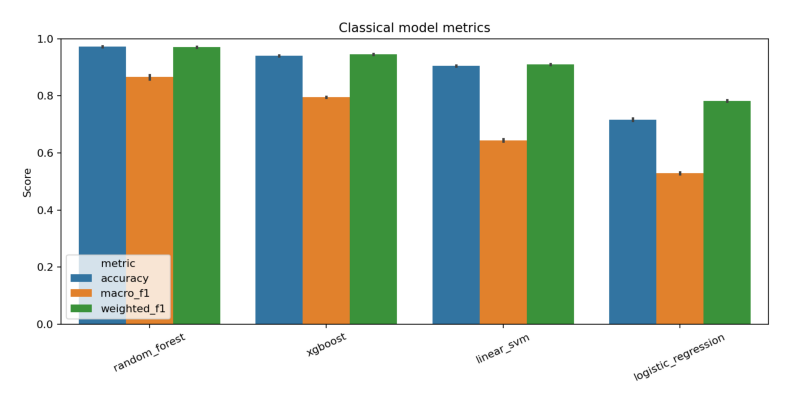

In [7]:
metric_plot = config.FIGURES_DIR / "classical_model_metrics.png"
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(plt.imread(metric_plot))
ax.axis("off");

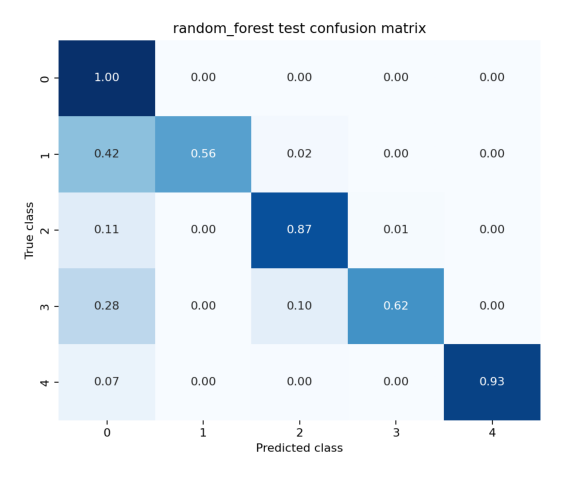

In [8]:
confusion_path = config.FIGURES_DIR / f"{best_model}_test_confusion_matrix.png"
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(plt.imread(confusion_path))
ax.axis("off");

## Current conclusion

Random forest is the best classical baseline in this pass. The result is credible enough to compare against a CNN, but not strong enough to ignore minority-class behavior. The next stage should use the same metrics and confusion-matrix checks for the raw-waveform CNN.